# 1주차: ESOL 분자 탐색과 descriptor baseline

이 노트북의 목표는 **하나의 분자를 화학 구조, RDKit 객체, graph tensor로 연결해서 이해**하고, 해석 가능한 descriptor만으로 용해도(logS)를 얼마나 예측할 수 있는지 확인하는 것입니다. 데이터 분할은 seed 42의 고정 80/10/10 random split이며, 다음 주 GNN도 같은 index를 사용합니다. 이번 주에는 GNN 학습과 scaffold split을 다루지 않습니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors

from ai4sci_molecule.week1 import (
    DESCRIPTOR_NAMES, EDGE_FEATURE_NAMES, NODE_FEATURE_NAMES,
    build_baselines, calculate_descriptors, load_esol,
    make_random_split, regression_metrics, smiles_to_graph,
)

SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

## 1. ESOL 불러오기와 기본 검증

PyG의 `MoleculeNet(root="data/MoleculeNet", name="ESOL")`은 Delaney ESOL 데이터의 각 분자를 `Data` 객체로 변환합니다. 최초 실행 때만 원본을 `data/MoleculeNet` 아래에 다운로드합니다.

In [2]:
dataset = load_esol(Path("..") / "data" / "MoleculeNet")
records = pd.DataFrame({
    "smiles": [graph.smiles for graph in dataset],
    "logS": [float(graph.y.item()) for graph in dataset],
    "num_nodes": [graph.num_nodes for graph in dataset],
    "num_directed_edges": [graph.num_edges for graph in dataset],
})

print(f"분자 수: {len(dataset):,}")
print("결측값 수:")
display(records.isna().sum().to_frame("missing").T)
display(records.head())

first = dataset[0]
print("첫 graph의 tensor shape:", {
    "x": tuple(first.x.shape),
    "edge_index": tuple(first.edge_index.shape),
    "edge_attr": tuple(first.edge_attr.shape),
    "y": tuple(first.y.shape),
})
assert len(dataset) == 1_128
assert not records.isna().any().any()

분자 수: 1,128
결측값 수:


,smiles,logS,num_nodes,num_directed_edges
missing,0,0,0,0


,smiles,logS,num_nodes,num_directed_edges
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,32,68
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,15,32
2,CC(C)=CCCC(C)=CC(=O),-2.06,11,20
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,22,52
4,c1ccsc1,-1.33,5,10


첫 graph의 tensor shape: {'x': (32, 9), 'edge_index': (2, 68), 'edge_attr': (68, 3), 'y': (1, 1)}


/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/4002420873.py:8: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_l

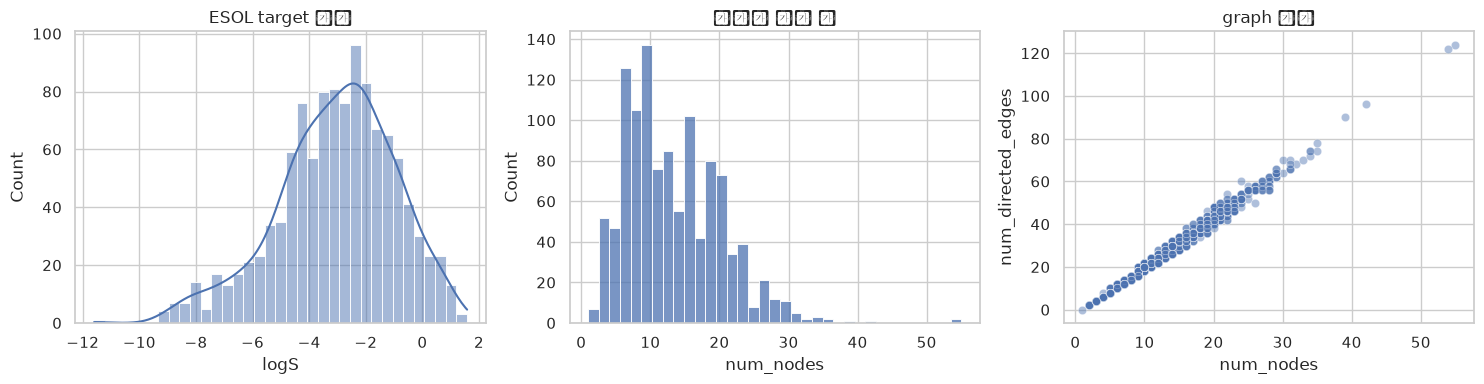

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(records, x="logS", bins=35, kde=True, ax=axes[0])
axes[0].set_title("ESOL target 분포")
sns.histplot(records, x="num_nodes", bins=35, ax=axes[1])
axes[1].set_title("분자별 원자 수")
sns.scatterplot(records, x="num_nodes", y="num_directed_edges", alpha=0.45, ax=axes[2])
axes[2].set_title("graph 크기")
plt.tight_layout()
plt.show()

`x`는 원자(node), `edge_index`는 연결 관계, `edge_attr`는 결합(edge), `y`는 graph 전체의 용해도입니다. PyG는 무방향 화학 결합 하나를 양방향 edge 두 개로 저장하므로 `num_directed_edges`는 일반적으로 RDKit 결합 수의 두 배입니다.

## 2. 구조적으로 다양한 분자 20개

분자량(MW), LogP, TPSA, ring 수, aromatic atom fraction, logS 각각의 작은 값과 큰 값을 순서대로 훑습니다. 중복 index는 건너뛰고 20개가 될 때까지 각 극단에서 다음 순위를 택하므로 선택은 결정론적입니다. 무작위 표본보다 데이터의 넓은 화학적·물성 범위를 빠르게 확인하기 좋습니다.

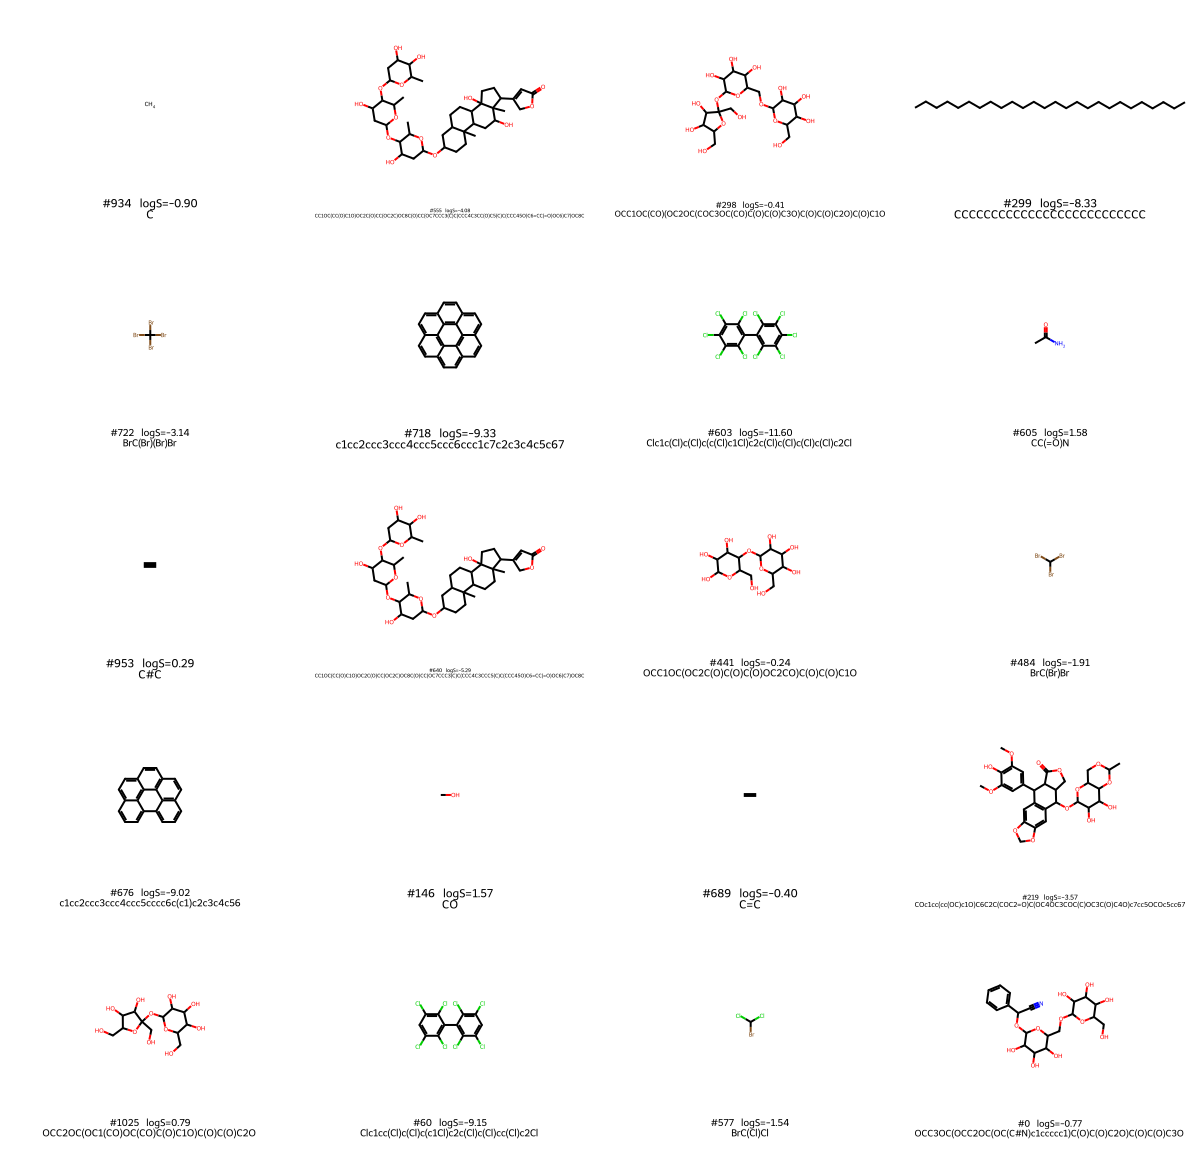

,smiles,logS,MolWt,MolLogP,TPSA,NumRotatableBonds,AromaticAtomFraction,RingCount
934,C,-0.900,16.043,0.636,0.00,0.0,0.000,0
555,CC1OC(CC(O)C1O)OC2C(O)CC(OC2C)OC8C(O)CC(OC7CCC...,-4.081,780.949,2.218,203.06,7.0,0.000,8
298,OCC1OC(CO)(OC2OC(COC3OC(CO)C(O)C(O)C3O)C(O)C(O...,-0.410,504.438,-7.571,268.68,8.0,0.000,3
299,CCCCCCCCCCCCCCCCCCCCCCCCCC,-8.334,366.718,10.389,0.00,23.0,0.000,0
722,BrC(Br)(Br)Br,-3.140,331.627,3.177,0.00,0.0,0.000,0
718,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332,300.360,6.919,0.00,0.0,1.000,7
603,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600,498.662,9.888,0.00,1.0,0.545,2
605,CC(=O)N,1.580,59.068,-0.508,43.09,0.0,0.000,0
953,C#C,0.290,26.038,0.249,0.00,0.0,0.000,0
640,CC1OC(CC(O)C1O)OC2C(O)CC(OC2C)OC8C(O)CC(OC7CCC...,-5.293,764.950,3.247,182.83,7.0,0.000,8


In [4]:
descriptors = calculate_descriptors(records["smiles"].tolist())
descriptors["RingCount"] = [
    rdMolDescriptors.CalcNumRings(Chem.MolFromSmiles(s)) for s in records["smiles"]
]
exploration = pd.concat([records[["smiles", "logS"]], descriptors], axis=1)

extreme_columns = ["MolWt", "MolLogP", "TPSA", "RingCount", "AromaticAtomFraction", "logS"]
rankings = []
for column in extreme_columns:
    rankings.append(exploration.sort_values([column, "smiles"], ascending=[True, True]).index.tolist())
    rankings.append(exploration.sort_values([column, "smiles"], ascending=[False, True]).index.tolist())

selected_indices, seen = [], set()
rank = 0
while len(selected_indices) < 20:
    for order in rankings:
        index = order[rank]
        if index not in seen:
            selected_indices.append(index)
            seen.add(index)
        if len(selected_indices) == 20:
            break
    rank += 1

selected = exploration.loc[selected_indices].copy()
molecules = [Chem.MolFromSmiles(s) for s in selected["smiles"]]
legends = [f"#{idx}  logS={row.logS:.2f}\n{row.smiles}" for idx, row in selected.iterrows()]
display(Draw.MolsToGridImage(molecules, molsPerRow=4, subImgSize=(300, 230), legends=legends))
display(selected.round(3))

## 3. `CCO`: RDKit 분자에서 graph tensor까지

에탄올 `CCO`에는 탄소 2개와 산소 1개가 있고 단일 결합은 2개입니다. 먼저 RDKit이 제공하는 원자·결합 속성을 표로 본 뒤, 같은 정보를 명시적인 feature tensor로 변환합니다.

In [5]:
ethanol_smiles = "CCO"
ethanol_mol = Chem.MolFromSmiles(ethanol_smiles)
atom_table = pd.DataFrame([{
    "atom_idx": atom.GetIdx(), "symbol": atom.GetSymbol(),
    "atomic_number": atom.GetAtomicNum(), "degree": atom.GetDegree(),
    "formal_charge": atom.GetFormalCharge(), "total_hydrogens": atom.GetTotalNumHs(),
    "is_aromatic": atom.GetIsAromatic(), "hybridization": str(atom.GetHybridization()),
} for atom in ethanol_mol.GetAtoms()])
bond_table = pd.DataFrame([{
    "begin": bond.GetBeginAtomIdx(), "end": bond.GetEndAtomIdx(),
    "bond_type": str(bond.GetBondType()), "is_conjugated": bond.GetIsConjugated(),
    "is_in_ring": bond.IsInRing(),
} for bond in ethanol_mol.GetBonds()])
display(atom_table)
display(bond_table)

,atom_idx,symbol,atomic_number,degree,formal_charge,total_hydrogens,is_aromatic,hybridization
0,0,C,6,1,0,3,False,SP3
1,1,C,6,2,0,2,False,SP3
2,2,O,8,1,0,1,False,SP3


,begin,end,bond_type,is_conjugated,is_in_ring
0,0,1,SINGLE,False,False
1,1,2,SINGLE,False,False


In [6]:
manual_ethanol = smiles_to_graph(ethanol_smiles, target=-0.30)
print("node feature 순서:", NODE_FEATURE_NAMES)
print(manual_ethanol.x)
print("\nedge feature 순서:", EDGE_FEATURE_NAMES)
print(manual_ethanol.edge_index)
print(manual_ethanol.edge_attr)
print("y:", manual_ethanol.y, "smiles:", manual_ethanol.smiles)
assert manual_ethanol.x.shape[0] == 3
assert manual_ethanol.edge_index.shape[1] == 4

node feature 순서: ('atomic_number', 'degree', 'formal_charge', 'total_hydrogens', 'is_aromatic', 'hybridization_SP', 'hybridization_SP2', 'hybridization_SP3', 'hybridization_SP3D', 'hybridization_SP3D2', 'hybridization_OTHER')
tensor([[6., 1., 0., 3., 0., 0., 0., 1., 0., 0., 0.],
        [6., 2., 0., 2., 0., 0., 0., 1., 0., 0., 0.],
        [8., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0.]])

edge feature 순서: ('bond_SINGLE', 'bond_DOUBLE', 'bond_TRIPLE', 'bond_AROMATIC', 'is_conjugated', 'is_in_ring')
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.]])
y: tensor([-0.3000]) smiles: CCO


수동 node feature는 원자번호, 차수, formal charge, 전체 수소 수, aromatic 여부, hybridization one-hot입니다. edge feature는 single/double/triple/aromatic one-hot, conjugated 여부, ring 여부입니다. `edge_index`에 `(0,1)`과 `(1,0)`, `(1,2)`와 `(2,1)`이 모두 있으므로 **2개 결합이 4개 directed edge**가 됩니다.

In [7]:
canonical_ethanol = Chem.MolToSmiles(ethanol_mol)
ethanol_hits = [
    i for i, smiles in enumerate(records["smiles"])
    if Chem.MolToSmiles(Chem.MolFromSmiles(smiles)) == canonical_ethanol
]
assert ethanol_hits, "ESOL에서 ethanol을 찾지 못했습니다."
pyg_ethanol = dataset[ethanol_hits[0]]
comparison = pd.DataFrame([
    {"표현": "수동 Data", "x": tuple(manual_ethanol.x.shape), "edge_index": tuple(manual_ethanol.edge_index.shape), "edge_attr": tuple(manual_ethanol.edge_attr.shape), "y": manual_ethanol.y.tolist(), "smiles": manual_ethanol.smiles},
    {"표현": "PyG MoleculeNet", "x": tuple(pyg_ethanol.x.shape), "edge_index": tuple(pyg_ethanol.edge_index.shape), "edge_attr": tuple(pyg_ethanol.edge_attr.shape), "y": pyg_ethanol.y.tolist(), "smiles": pyg_ethanol.smiles},
])
display(comparison)
print("PyG x:\n", pyg_ethanol.x)
print("PyG edge_index:\n", pyg_ethanol.edge_index)
print("PyG edge_attr:\n", pyg_ethanol.edge_attr)

,표현,x,edge_index,edge_attr,y,smiles
0,수동 Data,"(3, 11)","(2, 4)","(4, 6)",[-0.30000001192092896],CCO
1,PyG MoleculeNet,"(3, 9)","(2, 4)","(4, 3)",[[1.100000023841858]],CCO


PyG x:
 tensor([[6, 0, 4, 5, 3, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [8, 0, 2, 5, 1, 0, 4, 0, 0]])
PyG edge_index:
 tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])
PyG edge_attr:
 tensor([[1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0]])


두 `Data` 객체는 같은 분자 topology를 표현하지만 feature encoding은 다릅니다. PyG MoleculeNet의 내장 `x`와 `edge_attr`는 범주형 정수 encoding이고, 여기서 만든 수동 표현은 사람이 열 이름을 바로 읽을 수 있는 float feature입니다. `y`는 데이터셋의 실측 logS이며, 수동 예제의 `-0.30`은 API 연결을 보여 주기 위한 예시 target입니다.

## 4. Descriptor와 target 탐색

baseline은 MolWt, MolLogP, TPSA, rotatable bond 수, aromatic atom fraction의 5개 입력만 사용합니다. 상관관계는 선형 연관의 단서이지 인과관계가 아니며, descriptor끼리도 중복 정보를 가질 수 있습니다.

/tmp/ipykernel_11121/2679011794.py:6: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/2679011794.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/2679011794.py:6: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/jake/ai4sci-molecule/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jake/ai4sci-molecule/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jake/ai4sci-molecule/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


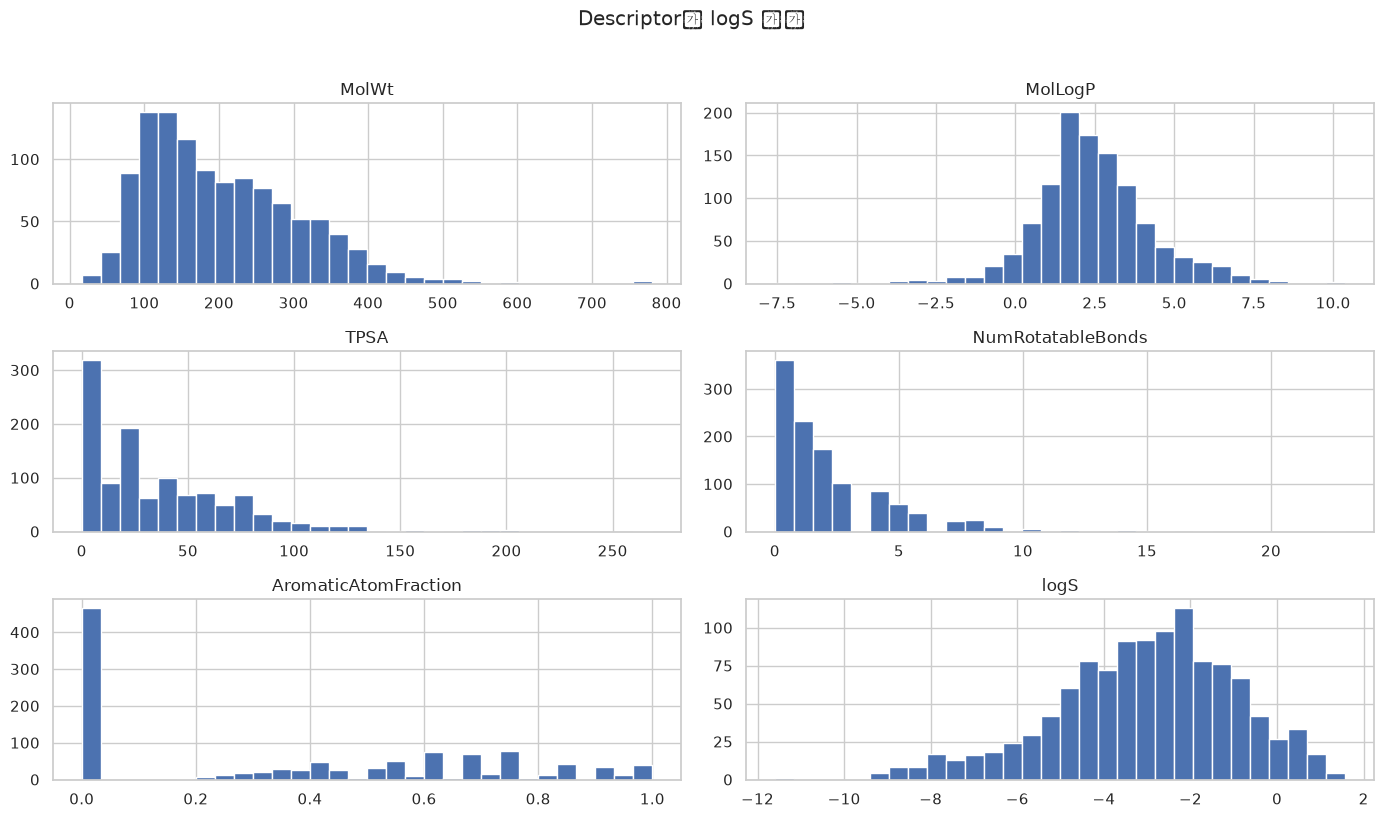

/tmp/ipykernel_11121/2679011794.py:12: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/2679011794.py:12: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/2679011794.py:12: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11121/2679011794.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jake/ai4sci-molecule/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jake/ai4sci-molecule/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

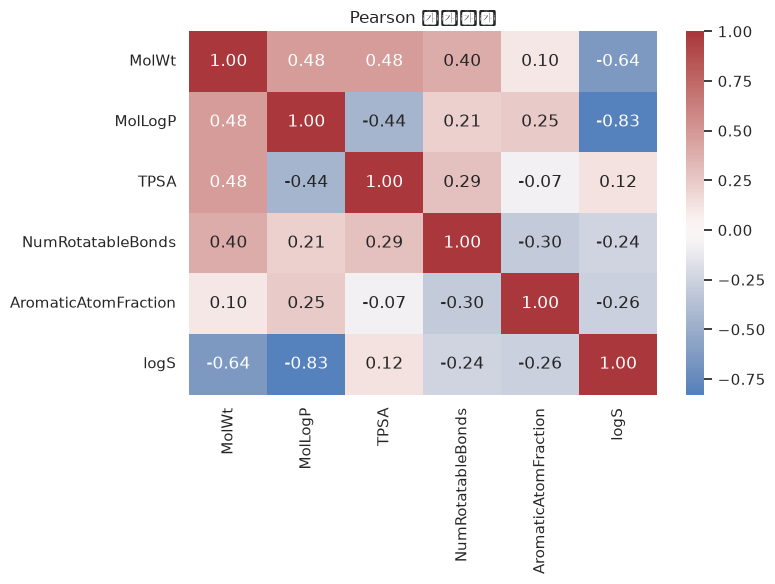

In [8]:
model_frame = pd.concat([descriptors[list(DESCRIPTOR_NAMES)], records[["logS"]]], axis=1)
assert not model_frame.isna().any().any()

model_frame.hist(figsize=(14, 8), bins=30)
plt.suptitle("Descriptor와 logS 분포", y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(model_frame.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Pearson 상관계수")
plt.tight_layout()
plt.show()

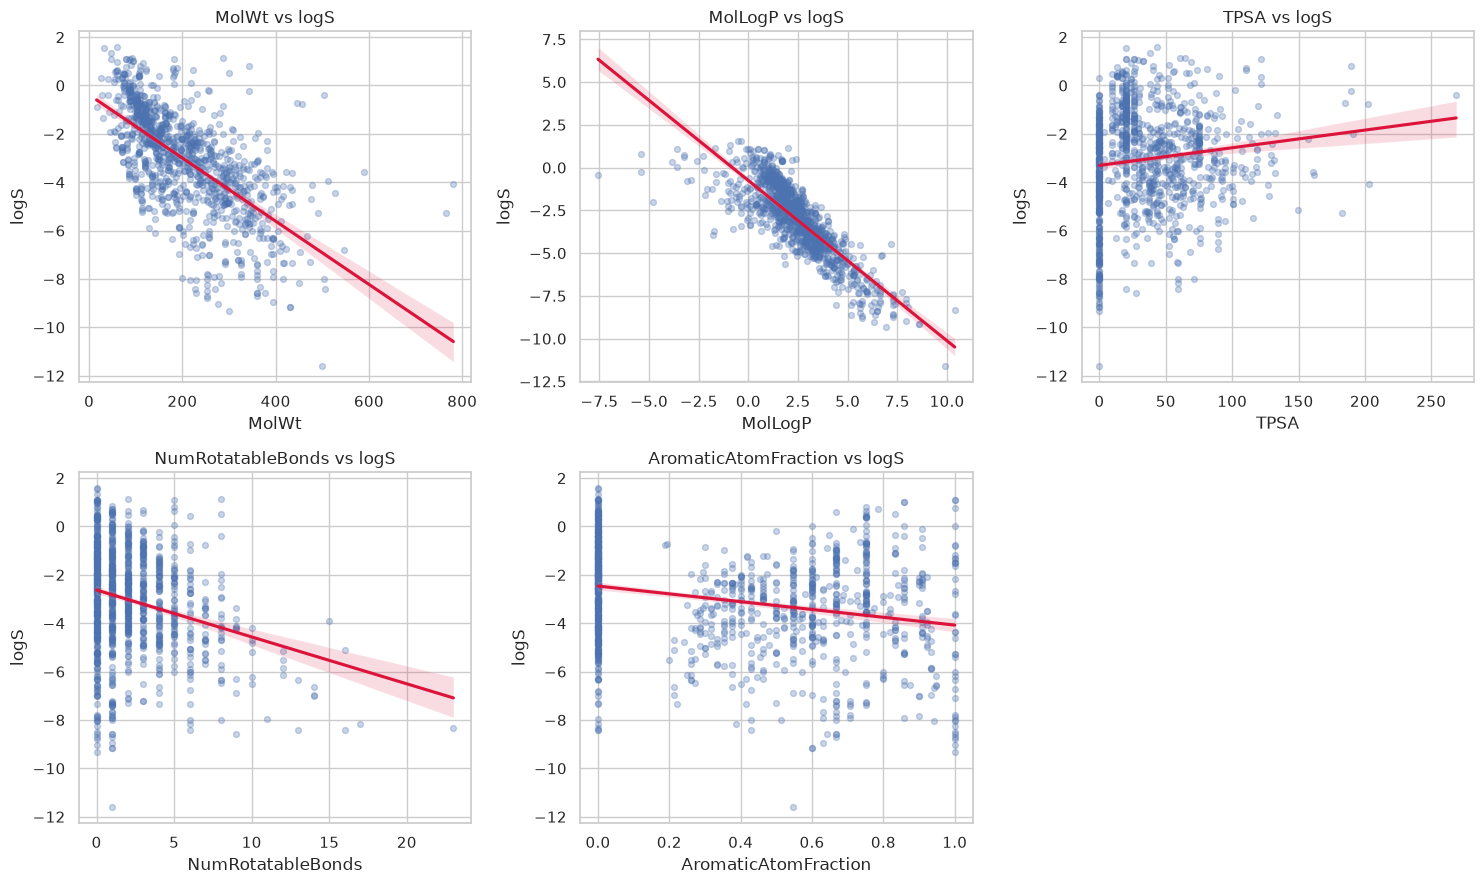

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, descriptor in zip(axes.flat, DESCRIPTOR_NAMES):
    sns.regplot(data=model_frame, x=descriptor, y="logS", scatter_kws={"alpha": 0.3, "s": 18}, line_kws={"color": "crimson"}, ax=axis)
    axis.set_title(f"{descriptor} vs logS")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

## 5. Dummy / Linear / MLP baseline

분할 index는 한 번만 만들고 세 모델 모두에 공유합니다. Dummy는 train target 평균만 예측합니다. Linear와 MLP 앞의 `StandardScaler`는 **train에서만 fit**되는 pipeline 안에 있어 validation/test 정보 누출을 막습니다. 먼저 validation으로 고정된 세 구성을 비교하고, 그 다음 cell에서 test를 각 모델당 정확히 한 번 평가합니다.

In [10]:
X = descriptors[list(DESCRIPTOR_NAMES)].to_numpy(dtype=float)
y = records["logS"].to_numpy(dtype=float)
split = make_random_split(len(dataset), seed=SEED)
print({name: len(index) for name, index in split.items()})
assert [len(split[k]) for k in ("train", "validation", "test")] == [902, 113, 113]

models = build_baselines(seed=SEED)
validation_rows = []
validation_predictions = {}
for name, model in models.items():
    model.fit(X[split["train"]], y[split["train"]])
    prediction = model.predict(X[split["validation"]])
    validation_predictions[name] = prediction
    validation_rows.append({"model": name, "split": "validation", **regression_metrics(y[split["validation"]], prediction)})

validation_metrics = pd.DataFrame(validation_rows)
display(validation_metrics.round(3))

{'train': 902, 'validation': 113, 'test': 113}


,model,split,RMSE,MAE,R2
0,Dummy (mean),validation,2.119,1.700,-0.002
1,Linear,validation,0.973,0.780,0.788
2,MLP,validation,0.837,0.672,0.843


In [11]:
# 모델 구성을 확정한 뒤 수행하는 유일한 최종 test 평가
test_rows = []
test_predictions = {}
for name, model in models.items():
    prediction = model.predict(X[split["test"]])
    test_predictions[name] = prediction
    test_rows.append({"model": name, "split": "test", **regression_metrics(y[split["test"]], prediction)})

metrics = pd.concat([validation_metrics, pd.DataFrame(test_rows)], ignore_index=True)
display(metrics.pivot(index="model", columns="split", values=["RMSE", "MAE", "R2"]).round(3))

RMSE               MAE                R2           
split          test validation   test validation   test validation
model                                                             
Dummy (mean)  1.999      2.119  1.607      1.700 -0.027     -0.002
Linear        0.910      0.973  0.738      0.780  0.787      0.788
MLP           0.730      0.837  0.578      0.672  0.863      0.843

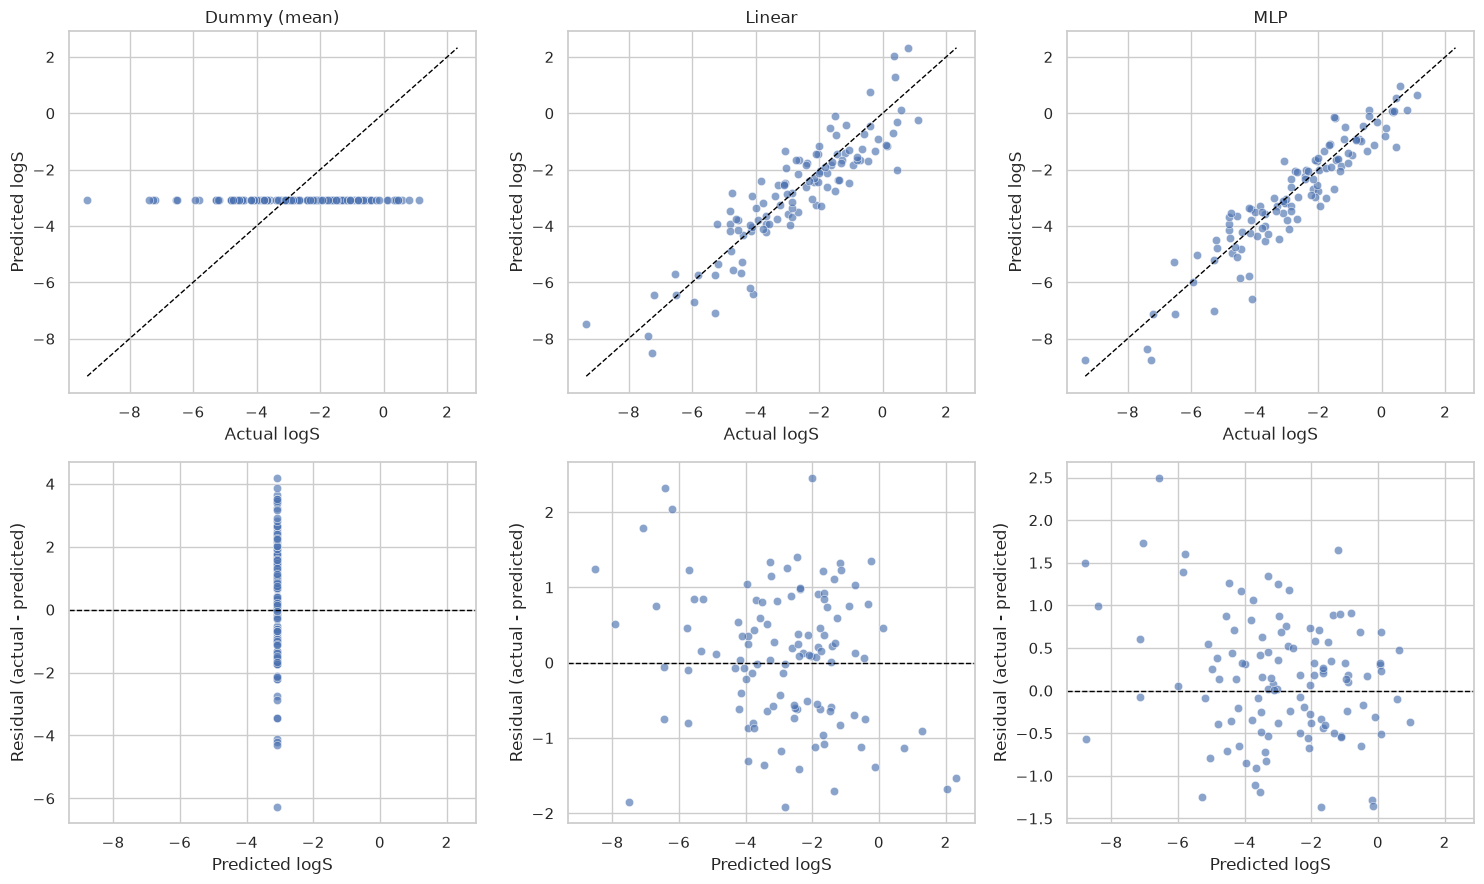

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex="row")
test_y = y[split["test"]]
limits = [min(test_y.min(), *(p.min() for p in test_predictions.values())), max(test_y.max(), *(p.max() for p in test_predictions.values()))]
for column, (name, prediction) in enumerate(test_predictions.items()):
    sns.scatterplot(x=test_y, y=prediction, alpha=0.65, ax=axes[0, column])
    axes[0, column].plot(limits, limits, "--", color="black", linewidth=1)
    axes[0, column].set(title=name, xlabel="Actual logS", ylabel="Predicted logS")
    residual = test_y - prediction
    sns.scatterplot(x=prediction, y=residual, alpha=0.65, ax=axes[1, column])
    axes[1, column].axhline(0, linestyle="--", color="black", linewidth=1)
    axes[1, column].set(xlabel="Predicted logS", ylabel="Residual (actual - predicted)")
plt.tight_layout()
plt.show()

Dummy의 actual-vs-predicted 점은 수평선에 놓입니다. 반면 Linear는 LogP·분자량·극성 등 descriptor의 가중합으로 분자별 차이를 학습하고, MLP는 descriptor 사이의 비선형 상호작용까지 표현할 수 있습니다. 따라서 Linear/MLP의 RMSE·MAE가 낮고 R²가 높다면 단순 평균을 넘어 실제 구조-물성 신호를 배운 것입니다. 다만 MLP가 항상 Linear보다 좋은 것은 아닙니다. 표본이 작고 입력이 5개뿐이라 복잡도가 오히려 불리할 수도 있으며, residual에 곡선이나 분산 변화가 남으면 descriptor 표현이나 모델 가정의 한계를 의심해야 합니다.

## 6. 해석의 한계와 다음 주 연결

- **random split의 낙관 가능성:** 유사한 scaffold를 가진 분자가 train과 test 양쪽에 들어가면 실제 새로운 화학 골격에 대한 일반화보다 점수가 좋게 보일 수 있습니다. scaffold split 비교는 후속 과제입니다.
- **작은 데이터:** 1,128개는 신경망에 작은 표본이며 split seed에 따라 metric 변동이 생길 수 있습니다. 이번에는 비교 가능성을 위해 seed 42를 고정했습니다.
- **descriptor의 한계:** 다섯 전역 descriptor는 원자 연결 순서, 작용기의 위치, stereochemistry, 3D conformation, 실험 조건을 충분히 표현하지 못합니다.
- **2D graph의 한계:** 다음 주 GNN도 결합 graph만 쓰면 3D 배치와 용매·온도 정보를 직접 보지 못합니다. GNN이 모든 화학 정보를 자동으로 해결하는 것은 아닙니다.
- **공정한 다음 주 비교:** GNN은 반드시 이번 `make_random_split(..., seed=42)`의 동일 index를 사용해야 합니다. 데이터가 달라지면 모델 표현력 차이와 표본 난이도 차이를 분리할 수 없습니다.

이번 결과는 ‘descriptor baseline보다 graph representation이 추가로 주는 정보가 있는가?’라는 다음 주 질문의 기준점입니다.